### Libraries

In [29]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
import sys
import seaborn as sns
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler

### part2_q9
میخواهیم بررسی کنیم خانه هایی که دارای بالکن اسانسور  نگهبان باربیکیو و استخر هستند عمدتا در کدام مناطق قرار دارند 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21044\3584067184.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Divar (1).csv')


colum : has_balcony 	 number of available data: 506411
persent of available data 50.6411
persent of true data : 4.086009190163721
colum : has_elevator 	 number of available data: 541749
persent of available data 54.1749
persent of true data : 67.40169340414103
colum : has_pool 	 number of available data: 29390
persent of available data 2.939
persent of true data : 12.660768969037086
colum : has_barbecue 	 number of available data: 31198
persent of available data 3.1198
persent of true data : 25.068914674017567
colum : has_security_guard 	 number of available data: 31312
persent of available data 3.1312
persent of true data : 21.33686765457333
0
0
732417


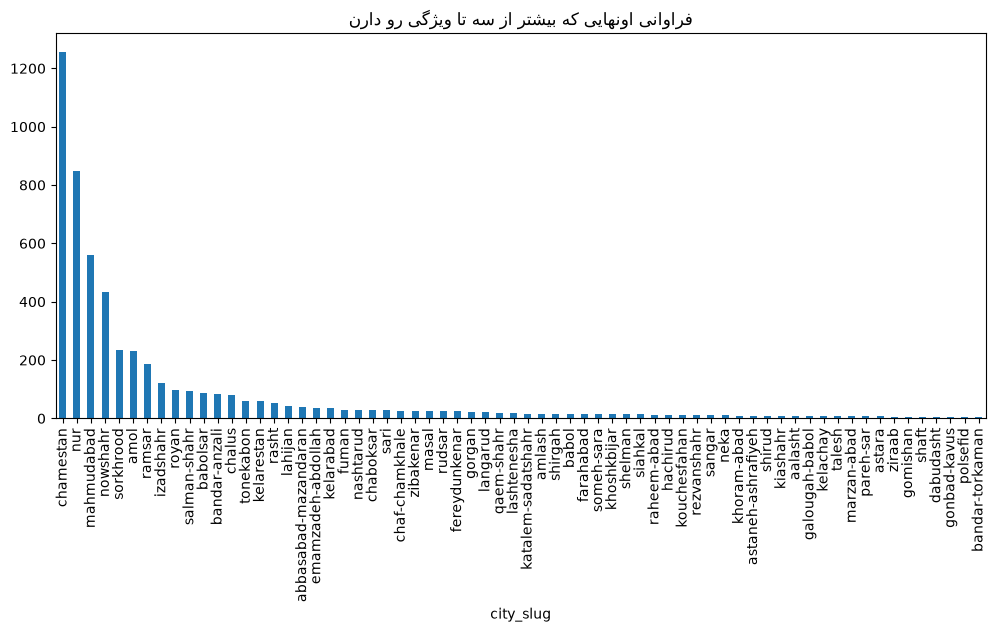

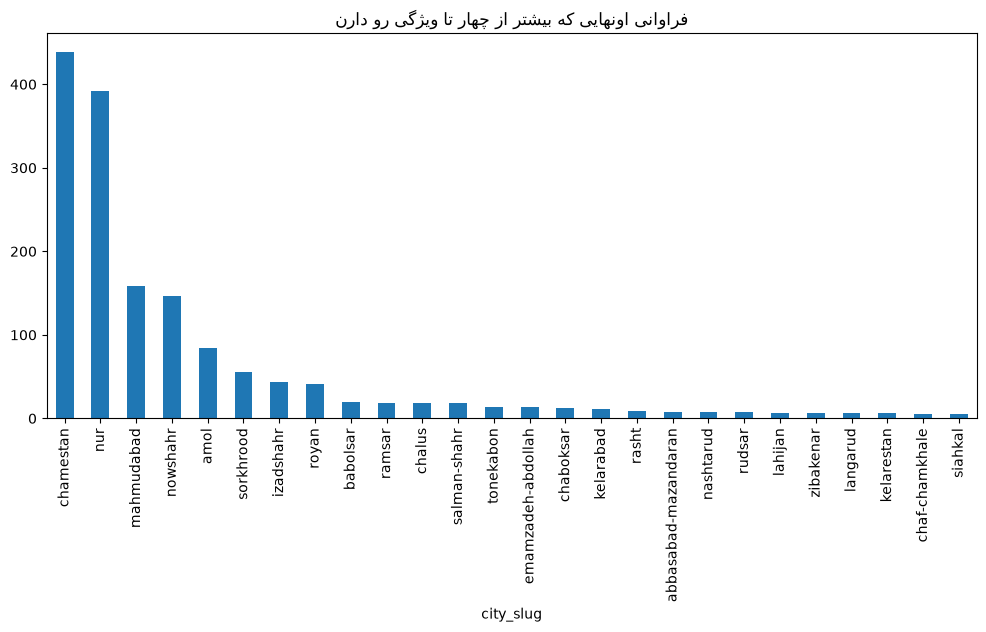

0
396


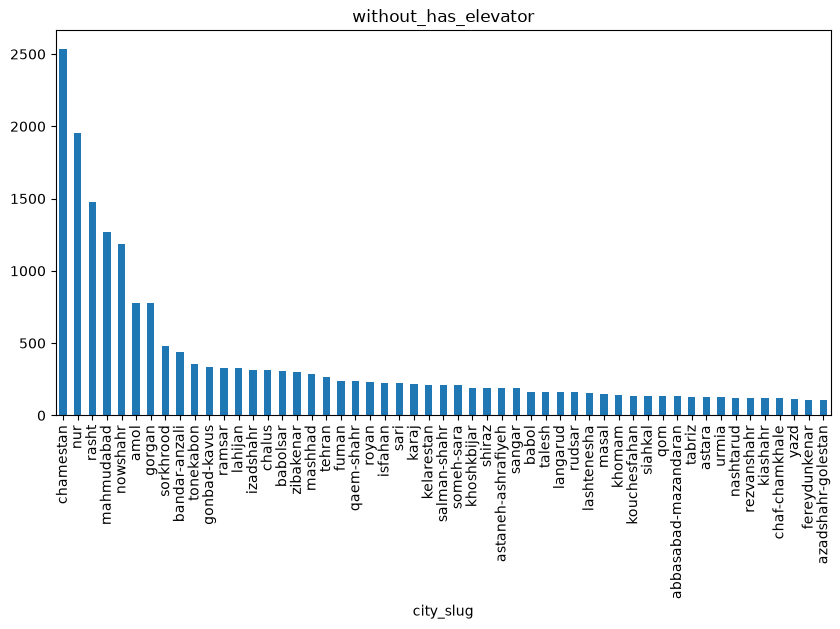

0
0
0


In [30]:
data = pd.read_csv('Divar (1).csv')
# بررسی کلی دیتا
# data.head()
# # print(data.describe())
# # print(data.info())
# data.sample( 20,random_state=44)
# ----------------------------------------------------------------------------------------------
# بررسی تعداد داده های موجود از هر ستون ودرصد داده های true
feature =['has_balcony','has_elevator','has_pool','has_barbecue','has_security_guard']
for j in feature:
    not_miss=(len(data)-data[j].isnull().sum())
    true=(data[j]==True).sum()
    print('colum :',j,'\t','number of available data:',not_miss)
    print("persent of available data",not_miss/10000)
    print('persent of true data :',(true/not_miss)*100)
# -----------------------------------------------------------------------------------------------
n = data[(data['has_balcony']==True) & (data['has_elevator']==True) & (data['has_pool']==True) & (data['has_barbecue']==True) & (data['has_security_guard']==True) ]
print(len(n))
# هیچ خونه ای که هر پنج ویژگی رو داشته باشه نداشتیم
print(data[feature].notnull().all(axis=1).sum())     
print(data[feature].notnull().any(axis=1).sum())
# پر کردن داده های میس شده با پیش فرض false چون منطقی تر بود
# ساخت ستون جدید برای شمارش تعداد ستون های درست از 5 ستون 
data['n_true'] = data[feature].fillna(False).astype(bool).sum(axis=1)
more_than3 = data[data['n_true']>=3]
more_than3['city_slug'].value_counts().head(10)
count3 = more_than3['city_slug'].value_counts()
count3 = count3[count3>=5]
count3.plot(kind='bar' , figsize=(12,5),title="فراوانی اونهایی که بیشتر از سه تا ویژگی رو دارن")
plt.show()
more_than4 = data[data['n_true']>=4]
more_than4['city_slug'].value_counts().head(10)
count4 = more_than4['city_slug'].value_counts()
count4 = count4[count4>=5]
count4.plot(kind='bar' , figsize=(12,5),title="فراوانی اونهایی که بیشتر از چهار تا ویژگی رو دارن")
plt.show()

for i in feature:
    data_5 = feature.copy()
    data_5.remove(i)
    full = data.dropna(subset=data_5)
    plot_full = full['city_slug'].value_counts()
    print(len(plot_full))
    if len(plot_full)==0 :
        continue
    plot_full = plot_full[plot_full>=100]
    # چون تعداد شهر ها خیلی زیاد بودگفتم فقط بیشتر از 100 تا رو که در واقع فراوون ها هستن نشون بده
    plot_full.plot(kind='bar',figsize=(10,5),title=f"without_{i}")
    plt.show()


### نتیجه گیری
 با توجه به اینکه هیچ شهری نبود که هر 5 ویژگی رو باهم داشته باشه و پر کردن داده با 1 کار منطقی نبود چون  مثلا از روی مساحت خونه یا غیره میخواهیم نتیجه گیری کنیم که 
 ممکنه یه خونه مساحت زیادی داشته باشه ولی استخر نداشته باشه با توجه به منطقه هم که خب ما اصلا قراره درباره منطقه خونه نتیجه گیری کنیم و اینجوری انگار پیش فرض 
 خودمون تو نتیجه دخیل بوده پس اون نتیجه دستکاری شده و در عین حال معمولا طبق چیزی که فرض میشه اگر خونه ای ویژگی خاصی رو داشته باشه مالک اون رو ذکر میکنه 
  پس داده های میس شده رو 0 در نظر گرفتم 
  اومدم بار پلات خونه هایی که 4 ویژگی از 5 ویژگی رو داشتن رو رسم کردم و نتیجه به سمت مناطق ویلایی وشمالی رفت بعد برای نتیجه گیری دقیق تر گفتم هربار یه ستون مشخص 
  رو نظر نمیگیریم و توزیع خونه هارو برای چهار تا ویژگی دیگه در نظر میگیرم 
  نتیجه واقعا جالب بود تعداد خونه ها برای اشتراک 4 حالت که ستون اسانسور داخل شون بود صفر شد!!
  اما وقتی کالم اسانسور رو حذف کردم به نتیجه ای مشابه نتیجه جدول اول رسیدم یعنی علت اینکه اشتراک صفر میشد ستون اسانسور بود و بقیه ستون ها باهم اشتراک داشتن و
  نتیجه همون مناطق شمالی ویلایی وتفریحی بود یعنی خونه های موجود تو این مناطق اکثر ان باربیکیو بالکن نگهبان واستخر دارن و عموما اسانسور ندارن و این باعث میشده که 
  اشتراک محدود بشه

In [31]:
count3.info()
count3.describe()

<class 'pandas.Series'>
Index: 66 entries, chamestan to bandar-torkaman
Series name: count
Non-Null Count  Dtype
--------------  -----
66 non-null     int64
dtypes: int64(1)
memory usage: 3.1+ KB


count      66.00000
mean       80.30303
std       200.05053
min         5.00000
25%         9.00000
50%        16.50000
75%        40.75000
max      1257.00000
Name: count, dtype: float64

###q2

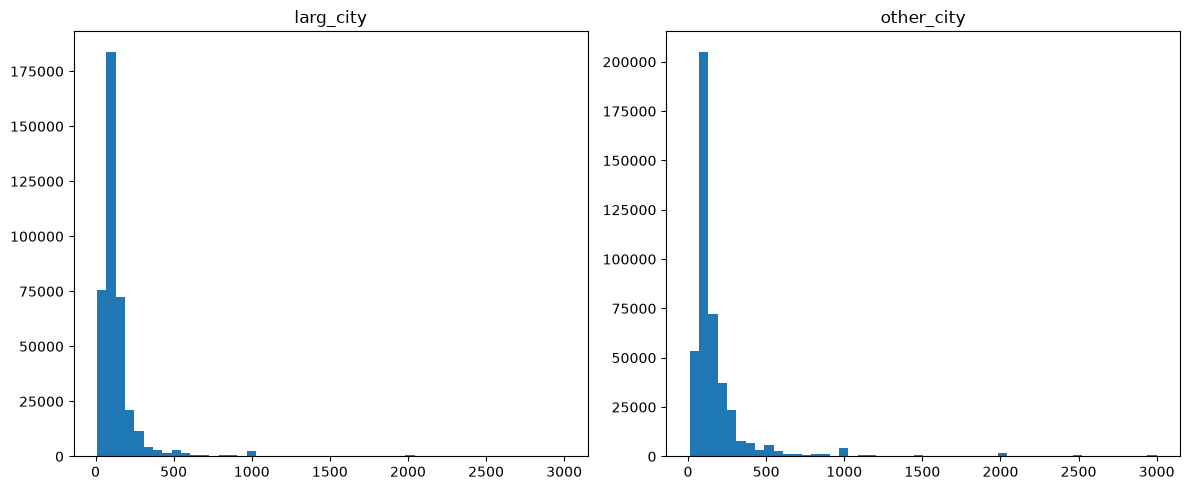

72770226263.0 
 0.0


In [33]:
city = pd.read_csv('iran_city_classification.csv')
city.head()
new = data.merge(city,left_on='city_slug',right_on='نام شهر',how='left')
new = new.drop(columns=['نام شهر'])
new = new[(new['cat2_slug']=='residential-sell') |(new['cat2_slug']=='residential-rent') ]
larg_city = new[new['دسته‌بندی']=='کلان‌شهر']
other_city = new[new['دسته‌بندی']!='کلان‌شهر']
larg_city['building_size'].describe()
larg_city = larg_city.drop(larg_city[larg_city['building_size']<10].index)
other_city = other_city.drop(other_city[other_city['building_size']<10].index)
larg_city = larg_city.drop(larg_city[larg_city['building_size']>3000].index)
other_city = other_city.drop(other_city[other_city['building_size']>3000].index)
# رسم هیستوگرام برای دیدن نرمال بودن یا نه
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(larg_city['building_size'], bins=50)
ax[0].set_title('larg_city')
ax[1].hist(other_city['building_size'], bins=50)
ax[1].set_title('other_city')
plt.tight_layout()
plt.show()
large = larg_city['building_size'].dropna()
other = other_city['building_size'].dropna()
# نرمال نبود یا باید بازه رو کوچیکتر کنم که به نرمال نزدیک بششه که کار درستی نیست توضیح میدم چرا
# فرض صفر: m_large_city >= m_other
# فرض الترنتیو:m_large_city < m_other
u , p_value = stats.mannwhitneyu(large,other,alternative='less')
print(u,'\n',p_value)
# other_city_mean = other_city['building_size'].describe()

In [ ]:
compare_u = len(large) * len(other)/2
print(compare_u)
print(u)

84182829627.0
72770226263.0


### clustering


In [34]:
# clustring
import sys
print(sys.executable)
!{sys.executable} -m pip install pyproj

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\python.exe



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
data[['transformable_price','price_value','transformable_credit','transformed_credit','credit_value','transformable_rent','transformed_rent','rent_value']].head(20)

,transformable_price,price_value,transformable_credit,transformed_credit,credit_value,transformable_rent,transformed_rent,rent_value
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN
2,False,NaN,7.500000e+08,NaN,7.500000e+08,26000000.0,NaN,26000000.0
3,False,NaN,9.500000e+08,NaN,9.500000e+08,95000000.0,NaN,95000000.0
4,NaN,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN
5,True,NaN,2.500000e+08,400000000.0,2.500000e+08,6000000.0,1.0,6000000.0
6,False,NaN,1.500000e+08,NaN,1.500000e+08,16000000.0,NaN,16000000.0
7,NaN,8.700000e+09,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,6.500000e+08,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,3.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN


0             NaN
1    8.500000e+09
2             NaN
3             NaN
4    5.750000e+09
Name: transform, dtype: float64
eps=0.5, min_samples=100 -> 3 کلاستر، نویز=316


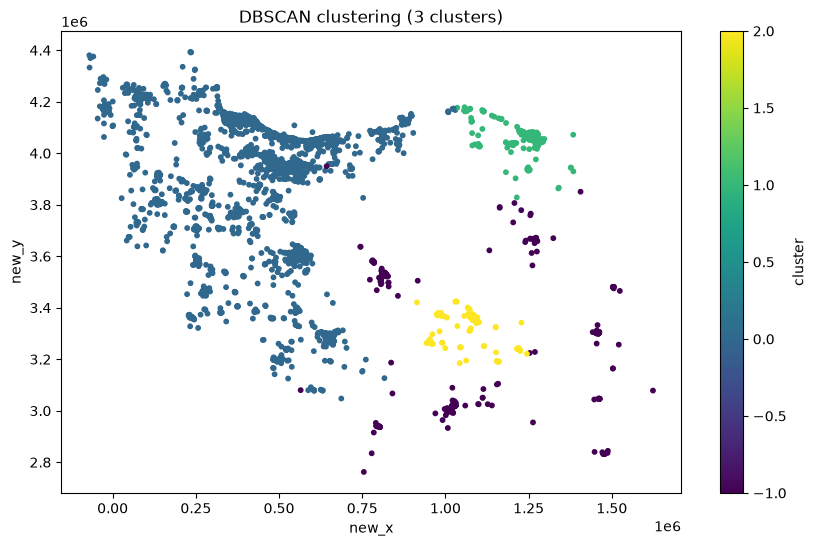

cluster
-1    5.678647e+11
 0    6.096332e+09
 1    4.762730e+09
 2    3.139026e+09
Name: transform, dtype: float64


In [36]:
tp = data['transformable_price'].fillna(False).astype(bool)

s = data[['transformed_credit', 'transformed_rent']].sum(axis=1, min_count=1)

data['transform'] = np.where(
    data['price_value'].notna(), data['price_value'],
    np.where(tp, s, np.nan)
)
print(data['transform'].head())
transformed = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
cluster_data = data[['location_latitude', 'location_longitude', 'transform']].copy()
x,y = transformed.transform(cluster_data['location_longitude'].values, cluster_data['location_latitude'].values)
cluster_data['new_x'] = x 
cluster_data['new_y'] = y
# cluster_data['transform'].plot(kind='hist',figsize=(10,5))

scaler = StandardScaler()
cluster_data = cluster_data[['new_x', 'new_y', 'transform']].dropna()
cluster_data = cluster_data.sample(n=10000, random_state=0)
cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
from sklearn.cluster import DBSCAN
dbs = DBSCAN(eps=0.3, min_samples=20)

result = dbs.fit_predict(cluster_data_s)

cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
for eps in [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
    for ms in [10, 20, 50, 100]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(cluster_data_s)
        k = len(set(lab)) - (1 if -1 in lab else 0)
        if k==3:
          print(f'eps={eps}, min_samples={ms} -> {k} کلاستر، نویز={(lab==-1).sum()}')
dbs = DBSCAN(eps=0.5, min_samples=100)
labels = dbs.fit_predict(cluster_data_s)

plt.figure(figsize=(10, 6))
plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1],
            c=labels, cmap='viridis', s=10)
plt.xlabel(cluster_data.columns[0])
plt.ylabel(cluster_data.columns[1])
plt.title('DBSCAN clustering (3 clusters)')
plt.colorbar(label='cluster')
plt.show()
cluster_data['cluster'] = labels
print(cluster_data.groupby('cluster')['transform'].mean())


In [37]:
data[['transformable_credit','transformed_credit']].sample(10,random_state=44)
data[['transformed_rent','transformable_rent']].sample(10,random_state=44)
data['transformable_credit'].describe()
data['rent_credit_transform'].describe()
data['price_value'].isnull().sum()
data['transformable_price'].describe()
print(data['price_value'].median())
print(data['transformable_credit'].median())
print(data['transformed_credit'].median())
print(data['transformed_rent'].median())
print(data['transformable_rent'].median())

2840000000.0
250000000.0
400000000.0
6000000.0
5000000.0


0             NaN
1    8.500000e+09
2    1.616667e+10
3    4.116667e+10
4    5.750000e+09
Name: transform, dtype: float64
0
eps=0.1, min_samples=150 تعدادکلاستر 3 کلاستر نویز=11667
eps=0.5, min_samples=150 تعدادکلاستر 3 کلاستر نویز=1284
eps=0.5, min_samples=230 تعدادکلاستر 3 کلاستر نویز=1809
eps=0.5, min_samples=250 تعدادکلاستر 3 کلاستر نویز=1889


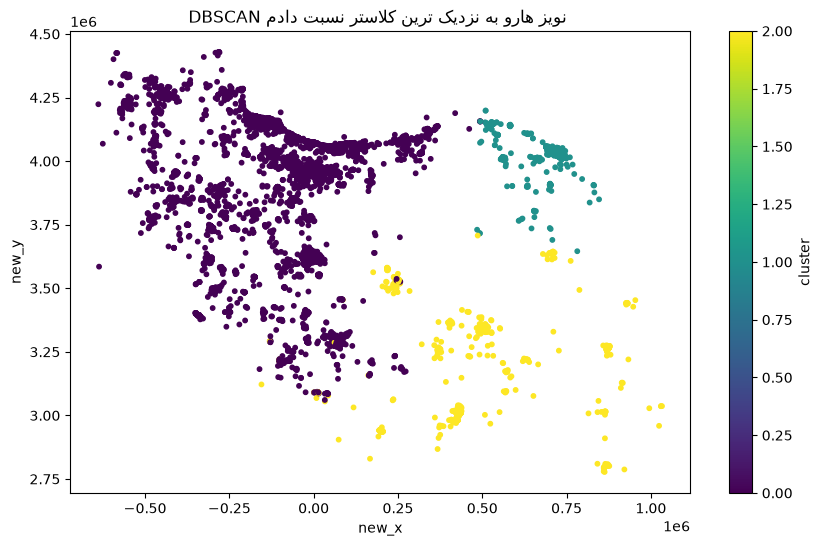

cluster
0    5.784592e+09
1    4.689497e+09
2    5.639235e+09
Name: transform, dtype: float64


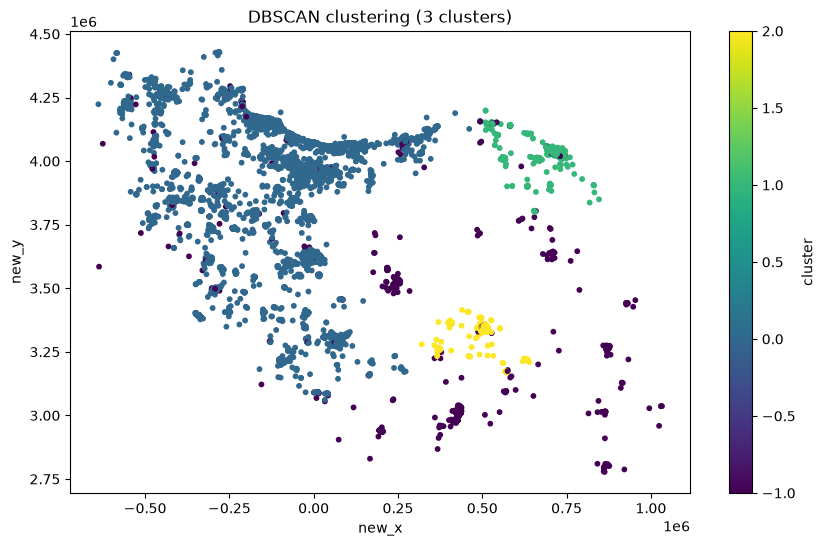

cluster
-1    1.220757e+10
 0    5.417596e+09
 1    3.641232e+09
 2    2.836270e+09
Name: transform, dtype: float64


In [40]:
tp = data['transformable_price'].fillna(False).astype(bool)

def calc_price(row):
    price, rent, credit = row.get("price_value"), row.get("rent_value"), row.get("credit_value")
    if pd.notna(price) :
        return price
    has_rent = pd.notna(rent) 
    has_credit = pd.notna(credit) 
    if has_rent and has_credit:
        return ((rent / 3) * 100 + credit) * 10
    if has_rent:
        return (rent / 3) * 100 * 10
    if has_credit:
        return credit * 100
    return np.nan
# //////////////////////////////////////////////////////////////////////////////
data['transform'] = data.apply(calc_price, axis=1)
print(data['transform'].head())
transformed = Transformer.from_crs("EPSG:4326",'EPSG:32640', always_xy=True)
cluster_data = data[['location_latitude', 'location_longitude', 'transform']].copy()
x,y = transformed.transform(cluster_data['location_longitude'].values, cluster_data['location_latitude'].values)
cluster_data['new_x'] = x 
cluster_data['new_y'] = y
cluster_data = cluster_data[
    cluster_data['new_x'].between(-700_000, 1_120_000) &cluster_data['new_y'].between(2_750_000, 4_500_000)]
mi,ma = cluster_data['transform'].quantile([0.03, 0.97])
cluster_data = cluster_data[cluster_data['transform'].between(mi, ma)]
# cluster_data['transform'].plot(kind='hist',figsize=(10,5))
print(cluster_data['transform'].isnull().sum())
cluster_data = cluster_data.dropna()
scaler = StandardScaler()
cluster_data = cluster_data[['new_x', 'new_y', 'transform']].dropna()
cluster_data = cluster_data.sample(n=20000, random_state=0)
cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
from sklearn.cluster import DBSCAN
cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
for eps in [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
    for ms in [10, 20, 50, 100,150,200,205,230,250]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(cluster_data_s)
        k = len(set(lab)) - (1 if -1 in lab else 0)
        if k==3:
           print(f'eps={eps}, min_samples={ms} تعدادکلاستر {k} کلاستر نویز={(lab==-1).sum()}')
dbs = DBSCAN(eps=0.5, min_samples=150)
labels = dbs.fit_predict(cluster_data_s)
#  مرکز هر کلاستر بدون نویز
unique_labels = [l for l in set(labels) if l != -1]
center= np.array([cluster_data_s[labels == l].mean(axis=0) for l in unique_labels])
#   نویزها به نزدیک‌ترین مرکز
noise_ = labels == -1
if noise_.any():
    noise_points = cluster_data_s[labels == -1]
    dists = np.linalg.norm(noise_points[:, None, :] - center[None, :, :], axis=2)
    nearest = np.argmin(dists, axis=1)
    labels[noise_] = np.array(unique_labels)[nearest]

cluster_data['cluster'] = labels
plt.figure(figsize=(10, 6))
plt.scatter(cluster_data['new_x'], cluster_data['new_y'],
            c=labels, cmap='viridis', s=10)
plt.xlabel('new_x'); plt.ylabel('new_y')
plt.title('DBSCAN نویز هارو به نزدیک ترین کلاستر نسبت دادم ')
plt.colorbar(label='cluster')
plt.show()
# /////////////////////////////////////////////////////////////////////////////////
print(cluster_data.groupby('cluster')['transform'].mean())
# ////////////////////////////////////////////////////////////////////
labels = dbs.fit_predict(cluster_data_s)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_data.iloc[:,0], cluster_data.iloc[:,1],c=labels, cmap='viridis', s=10)
plt.xlabel(cluster_data.columns[0])
plt.ylabel(cluster_data.columns[1])
plt.title('DBSCAN clustering (3 clusters)')
plt.colorbar(label='cluster')
plt.show()
cluster_data['cluster'] = labels
print(cluster_data.groupby('cluster')['transform'].mean())
